# 1. IMPORT LIBRARIES + DATASET

In [19]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
card = pd.read_csv("Data_Card.csv")

# 2. FIRST GLANCE

In [21]:
# 5 dòng đầu tiên
card.head()

,MONTH,COUNT_CREDITCARD,COUNT_DEBITCARD,CUSTOMER_NUMBER
0,9/30/2019,0,1,914326
1,4/30/2019,0,1,914326
2,11/30/2019,0,1,914326
3,8/31/2019,0,1,914326
4,12/31/2019,0,1,914326


In [22]:
# 10 dòng ngẫu nhiên
card.sample(10)

,MONTH,COUNT_CREDITCARD,COUNT_DEBITCARD,CUSTOMER_NUMBER
261794,12/31/2019,0,1,467521
449366,11/30/2019,1,0,26556
543736,9/30/2019,0,1,799829
27340,11/30/2019,0,1,742079
119856,1/31/2019,0,1,389468
780112,12/31/2019,0,1,393059
682616,4/30/2019,1,0,417857
769438,9/30/2019,0,1,164179
577264,9/30/2019,1,0,668549
228688,6/30/2019,0,1,728227


In [23]:
# Mô tả dữ liệu
print("--- DESCRIPTION ---")
card.describe(include = "all")

--- DESCRIPTION ---


,MONTH,COUNT_CREDITCARD,COUNT_DEBITCARD,CUSTOMER_NUMBER
count,871589,871589.000000,871589.000000,871589.000000
unique,12,NaN,NaN,NaN
top,12/31/2019,NaN,NaN,NaN
freq,150459,NaN,NaN,NaN
mean,NaN,0.297652,0.792835,501625.555724
std,NaN,0.506791,0.544715,288432.950598
min,NaN,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.000000,251821.000000
50%,NaN,0.000000,1.000000,502600.000000
75%,NaN,1.000000,1.000000,751193.000000


In [24]:
# Thông tin cơ bản
print("--- INFORMATION ---")
card.info()

--- Thông tin cơ bản ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871589 entries, 0 to 871588
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   MONTH             871589 non-null  object
 1   COUNT_CREDITCARD  871589 non-null  int64 
 2   COUNT_DEBITCARD   871589 non-null  int64 
 3   CUSTOMER_NUMBER   871589 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 26.6+ MB


In [25]:
# Kích thước
print("--- SHAPE ---")
print(f"Số dòng: {card.shape[0]} dòng")
print(f"Số cột: {card.shape[1]} cột")

--- Shape ---
Số dòng: 871589 dòng
Số cột: 4 cột


In [26]:
print("--- CHECK MISSING VALUES")
card.isna().sum()

--- CHECK MISSING VALUES


MONTH               0
COUNT_CREDITCARD    0
COUNT_DEBITCARD     0
CUSTOMER_NUMBER     0
dtype: int64

Tuyệt vời, ko thiếu gì cả

# 3. DATA CLEANING

Trước hết thì vẫn là chuẩn hoá kiểu dữ liệu

In [27]:
card["MONTH"] = pd.to_datetime(card["MONTH"], errors = "coerce")

# Check lại
card["MONTH"].info()
card.head()

<class 'pandas.core.series.Series'>
RangeIndex: 871589 entries, 0 to 871588
Series name: MONTH
Non-Null Count   Dtype         
--------------   -----         
871589 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 6.6 MB


,MONTH,COUNT_CREDITCARD,COUNT_DEBITCARD,CUSTOMER_NUMBER
0,2019-09-30,0,1,914326
1,2019-04-30,0,1,914326
2,2019-11-30,0,1,914326
3,2019-08-31,0,1,914326
4,2019-12-31,0,1,914326


In [28]:
print(f"Số lượng thẻ credit card có trong bảng{card['COUNT_CREDITCARD'].unique()}")
print(f"Số lượng thẻ debit card có trong bảng{card['COUNT_DEBITCARD'].unique()}")

Số lượng thẻ credit card có trong bảng[ 0  1  2  3  5  4  6 11 10  8 13  7]
Số lượng thẻ debit card có trong bảng[ 1  0  2  3  6  5  7  4 10  9  8 11 18 15 12 19]


## 3.1. EDA

In [29]:
print("--- THỐNG KÊ SỐ LƯỢNG THẺ / KHÁCH HÀNG ---")
# Tổng hợp theo khách hàng (lấy bản ghi mới nhất hoặc max các tháng để xem phân phối)
customer_card_summary = card.groupby("CUSTOMER_NUMBER").agg(
    MAX_CREDIT = ("COUNT_CREDITCARD", "max"),
    MAX_DEBIT = ("COUNT_DEBITCARD", "max"),
    MEAN_CREDIT = ("COUNT_CREDITCARD", "mean"),
    MEAN_DEBIT = ("COUNT_DEBITCARD", "mean"),
    TOTAL_RECORDS = ("MONTH", "count")
).reset_index()

print(customer_card_summary[["MAX_CREDIT", "MAX_DEBIT"]].describe())

--- THỐNG KÊ SỐ LƯỢNG THẺ / KHÁCH HÀNG ---
          MAX_CREDIT      MAX_DEBIT
count  150459.000000  150459.000000
mean        0.307964       0.812328
std         0.523111       0.575996
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       1.000000
75%         1.000000       1.000000
max        13.000000      19.000000


In [30]:
print("--- PHÂN PHỐI SỐ LƯỢNG THẺ TỐI ĐA SỞ HỮU ---")
print("Credit Card distribution:")
print(customer_card_summary["MAX_CREDIT"].value_counts().sort_index())
print("\nDebit Card distribution:")
print(customer_card_summary["MAX_DEBIT"].value_counts().sort_index())

--- PHÂN PHỐI SỐ LƯỢNG THẺ TỐI ĐA SỞ HỮU ---
Credit Card distribution:
MAX_CREDIT
0     108085
1      38759
2       3364
3        202
4         34
5          5
6          5
7          1
10         1
11         2
13         1
Name: count, dtype: int64

Debit Card distribution:
MAX_DEBIT
0      37807
1     105199
2       6107
3        988
4        194
5         55
6         52
7         28
8          9
9          6
10         5
11         5
12         3
19         1
Name: count, dtype: int64


In [31]:
sns.set_theme(style = "whitegrid")

# Tổng hợp số lượng thẻ lưu hành theo tháng trên toàn hệ thống
monthly_trend = card.groupby("MONTH").agg(
    TOTAL_CREDIT = ("COUNT_CREDITCARD", "sum"),
    TOTAL_DEBIT = ("COUNT_DEBITCARD", "sum"),
    ACTIVE_CUSTOMERS = ("CUSTOMER_NUMBER", "nunique")
).reset_index().sort_values("MONTH")

print("--- XU HƯỚNG THEO THÁNG ---")
print(monthly_trend)

--- XU HƯỚNG THEO THÁNG ---
        MONTH  TOTAL_CREDIT  TOTAL_DEBIT  ACTIVE_CUSTOMERS
0  2019-01-31          2998         5404              8147
1  2019-02-28          4441         9073             13062
2  2019-03-31          6977        17023             22977
3  2019-04-30         10348        28541             37193
4  2019-05-31         14032        38451             49842
5  2019-06-30         18177        47177             61561
6  2019-07-31         22159        57838             74813
7  2019-08-31         26866        70593             89936
8  2019-09-30         31084        83379            104342
9  2019-10-31         35639        99978            122806
10 2019-11-30         40373       111347            136451
11 2019-12-31         46336       122222            150459


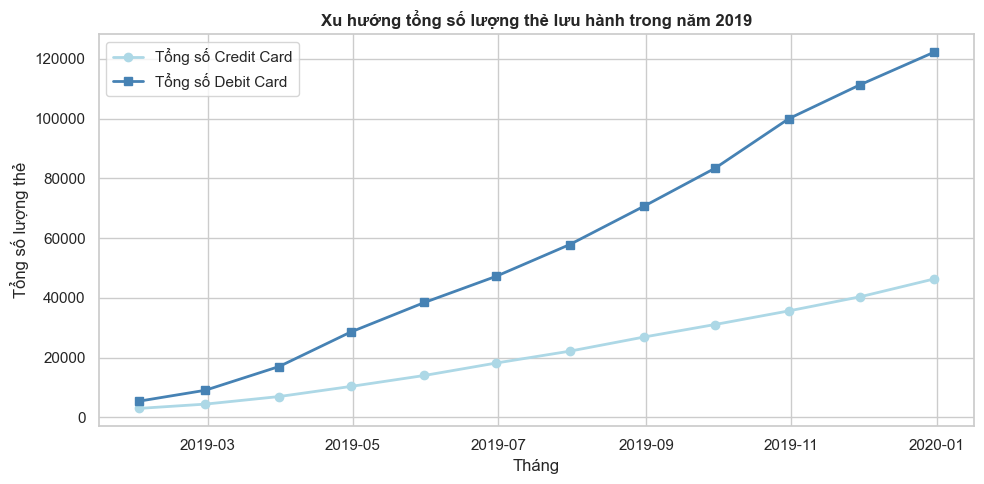

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_trend["MONTH"], monthly_trend["TOTAL_CREDIT"], marker = "o", label = "Tổng số Credit Card", color = "lightblue", linewidth = 2)
ax.plot(monthly_trend["MONTH"], monthly_trend["TOTAL_DEBIT"], marker = "s", label = "Tổng số Debit Card", color = "steelblue", linewidth = 2)
ax.set_title("Xu hướng tổng số lượng thẻ lưu hành trong năm 2019", fontsize = 12, fontweight = "bold")
ax.set_xlabel("Tháng")
ax.set_ylabel("Tổng số lượng thẻ")
ax.legend()
plt.tight_layout()
plt.show()

## 3.2. Preprocessing

In [33]:
# Áp dụng Observation Window (Chỉ lấy dữ liệu từ tháng 1/2019 đến hết tháng 9/2019)
cutoff_date = pd.Timestamp("2019-10-01")
card_obs = card[card["MONTH"] < cutoff_date].copy()

print(f"Số dòng dữ liệu trong Observation Window (< 2019-10-01): {len(card_obs)}")

Số dòng dữ liệu trong Observation Window (< 2019-10-01): 461873


In [34]:
# 3. Trích xuất SNAPSHOT TẠI THÁNG GẦN NHẤT (Tháng 9/2019)
# Lọc lấy tháng lớn nhất có trong window của từng khách hàng (thường là tháng 9 nếu active đều)
idx_latest = card_obs.groupby("CUSTOMER_NUMBER")["MONTH"].idxmax()
card_latest = card_obs.loc[idx_latest].copy()

feat_card_snapshot = card_latest[["CUSTOMER_NUMBER", "COUNT_CREDITCARD", "COUNT_DEBITCARD"]].rename(
    columns={
        "COUNT_CREDITCARD": "LATEST_CREDITCARD_COUNT",
        "COUNT_DEBITCARD": "LATEST_DEBITCARD_COUNT",
    }
)

# Tạo cờ nhị phân (Binary Flags) thể hiện hiện trạng sở hữu thẻ
feat_card_snapshot["HAS_CREDITCARD_OBS"] = (feat_card_snapshot["LATEST_CREDITCARD_COUNT"] > 0).astype(int)
feat_card_snapshot["HAS_DEBITCARD_OBS"] = (feat_card_snapshot["LATEST_DEBITCARD_COUNT"] > 0).astype(int)

In [35]:
# Trích xuất lịch sử biến động (Card History & Trend trong Q1 - Q3)
# - Tổng số tháng xuất hiện (active card)
# - Số lượng thẻ Credit/Debit tối đa từng đạt được trong giai đoạn
# - Biến động (Delta): So sánh số lượng thẻ giữa tháng cuối (T9) và tháng đầu tiên xuất hiện (T1)
# - groupby().first()/.last() lấy theo thứ tự dòng xuất hiện trong dataframe

card_obs_sorted = card_obs.sort_values(["CUSTOMER_NUMBER", "MONTH"])

card_history = card_obs_sorted.groupby("CUSTOMER_NUMBER").agg(
    CARD_ACTIVE_MONTHS = ("MONTH", "nunique"),
    MAX_HIST_CREDITCARD = ("COUNT_CREDITCARD", "max"),
    MAX_HIST_DEBITCARD = ("COUNT_DEBITCARD", "max"),
)

# Tính xu hướng mở/đóng thẻ (Lấy giá trị tháng cuối trừ tháng đầu tiên ghi nhận)
first_records = card_obs_sorted.groupby("CUSTOMER_NUMBER").first()
last_records = card_obs_sorted.groupby("CUSTOMER_NUMBER").last()

card_history["CREDITCARD_GROWTH"] = last_records["COUNT_CREDITCARD"] - first_records["COUNT_CREDITCARD"]
card_history["DEBITCARD_GROWTH"] = last_records["COUNT_DEBITCARD"] - first_records["COUNT_DEBITCARD"]
card_history = card_history.reset_index()

card_history.head()

,CUSTOMER_NUMBER,CARD_ACTIVE_MONTHS,MAX_HIST_CREDITCARD,MAX_HIST_DEBITCARD,CREDITCARD_GROWTH,DEBITCARD_GROWTH
0,0,1,0,1,0,0
1,3,6,0,1,0,0
2,8,5,1,0,0,0
3,13,1,0,1,0,0
4,14,3,1,0,0,0


In [36]:
# Gộp các nhóm feature của bảng Card lại thành 1 bảng chuẩn Customer-level duy nhất
# FIX: feat_card_snapshot và card_history đều được tạo ra từ cùng card_obs,
# nên tập CUSTOMER_NUMBER giữa 2 bảng giống hệt nhau -> dùng "left" (hoặc "inner")
# rõ nghĩa hơn "outer", tránh gây hiểu nhầm là có customer lệch nhau giữa 2 bảng.
card_feature_table = feat_card_snapshot.merge(card_history, on = "CUSTOMER_NUMBER", how = "left")

# Xử lý missing values (với những khách hàng không có trong bảng card, fill = 0)
fill_zeros = [
    "LATEST_CREDITCARD_COUNT", "LATEST_DEBITCARD_COUNT",
    "HAS_CREDITCARD_OBS", "HAS_DEBITCARD_OBS",
    "CARD_ACTIVE_MONTHS", "MAX_HIST_CREDITCARD", "MAX_HIST_DEBITCARD",
    "CREDITCARD_GROWTH", "DEBITCARD_GROWTH"
]
card_feature_table[fill_zeros] = card_feature_table[fill_zeros].fillna(0)

print(f"Kích thước bảng feature Card sau khi xử lý: {card_feature_table.shape}")
card_feature_table.head()

Kích thước bảng feature Card sau khi xử lý: (104342, 10)


,CUSTOMER_NUMBER,LATEST_CREDITCARD_COUNT,LATEST_DEBITCARD_COUNT,HAS_CREDITCARD_OBS,HAS_DEBITCARD_OBS,CARD_ACTIVE_MONTHS,MAX_HIST_CREDITCARD,MAX_HIST_DEBITCARD,CREDITCARD_GROWTH,DEBITCARD_GROWTH
0,0,0,1,0,1,1,0,1,0,0
1,3,0,1,0,1,6,0,1,0,0
2,8,1,0,1,0,5,1,0,0,0
3,13,0,1,0,1,1,0,1,0,0
4,14,1,0,1,0,3,1,0,0,0


In [37]:
card_feature_table.to_csv("card_clean.csv", index = False)
print("Đã lưu thành công file: card_clean.csv")

Đã lưu thành công file: card_clean.csv
